In [ ]:
#  Google Play Store Data Analysis

In [ ]:
##  Importing Required Libraries

import numpy as np
import pandas as pd

In [ ]:
##  Loading Dataset

df = pd.read_csv("E:/Data Sets/Play Store Data (1).csv")
Review = pd.read_csv("E:/Data Sets/User Reviews.csv")

print(df, Review)

                                                     App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE   

       Rating Reviews      

In [ ]:
##  Data Cleaning – Handling Missing Values

df.isnull().sum()


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [ ]:
df = df.dropna(subset=['Rating'])

# Fill remaining nulls with mode
for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove invalid ratings
df = df[df['Rating'] <= 5]

for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [ ]:
##  Data Type Conversion

#Clean & convert Installs

df['Installs'] = df['Installs'].astype(str)

df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')

df['Installs'] = pd.to_numeric(df['Installs'])

#Clean & convert Reviews

df['Reviews'] = pd.to_numeric(df['Reviews'])

#Clean & convert Size

df['Size'] = df['Size'].astype(str)

# Remove 'M'

df['Size'] = df['Size'].str.replace('M', '')

# Convert 'k' to MB

df['Size'] = df['Size'].str.replace('k', '')

# Remove unwanted rows

df = df[df['Size'] != 'Varies with device']

# Convert to numeric

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

# Convert KB to MB

df.loc[df['Size'] < 1, 'Size'] = df['Size'] / 1024
##  Converting Last Updated Column

df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [ ]:
##  Applying Filters

filtered_df = df[
    (df['Rating'] >= 4.0) &
    (df['Size'] >= 10) &
    (df['Last Updated'].dt.month == 1)
]
filtered_df.shape

(141, 13)

In [ ]:
##  Identifying Top 10 Categories

top_categories = (
    filtered_df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

Category
FAMILY             182504820
SPORTS             120511000
GAME               115741000
ENTERTAINMENT       21000000
PERSONALIZATION     15071500
TOOLS               12025000
PHOTOGRAPHY         10500000
LIFESTYLE            5071000
EDUCATION            2000000
COMMUNICATION        1100100
Name: Installs, dtype: int64

In [ ]:
#Create dataframe using these top categories

df_top = filtered_df[
    filtered_df['Category'].isin(top_categories.index)
]

In [ ]:
#Aggregation

grouped = df_top.groupby('Category').agg({
    'Rating': 'mean',
    'Reviews': 'sum'
}).reset_index()


In [ ]:
# Rename columns

grouped.rename(columns={
    'Rating': 'Average Rating',
    'Reviews': 'Total Reviews'
}, inplace=True)

grouped.head()
grouped.dtypes

Category              str
Average Rating    float64
Total Reviews       int64
dtype: object

In [ ]:
##  Time-Based Display Condition

from datetime import datetime

current_time = datetime.now()

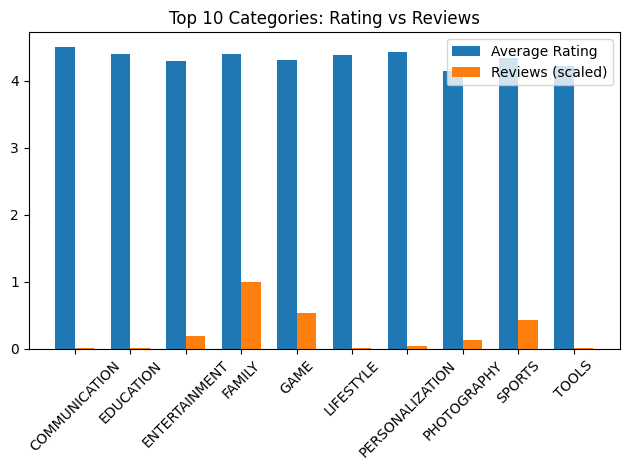

In [ ]:
##  Data Visualization

#Plotting Grouped Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Step 1: Create scaled reviews column
grouped['Reviews_scaled'] = grouped['Total Reviews'] / grouped['Total Reviews'].max()

# Step 2: Prepare x-axis
x = np.arange(len(grouped['Category']))
width = 0.35

# Step 3: Plot bars
plt.bar(x - width/2, grouped['Average Rating'], width, label='Average Rating')
plt.bar(x + width/2, grouped['Reviews_scaled'], width, label='Reviews (scaled)')

# Step 4: Labels and title
plt.xticks(x, grouped['Category'], rotation=45)
plt.title('Top 10 Categories: Rating vs Reviews')
plt.legend()

# Step 5: Show plot
plt.tight_layout()
plt.show()